# Infectious Disease Surveillance and Intervention Analysis

**Domain:** Public Health  
**Dataset:** CDC FluView ILINet data via Delphi Epidata API  
**Language:** Python

---

## Business Problem

Disease surveillance systems monitor population-level health trends over time, detecting seasonal patterns, outbreak signals, and the effects of public health interventions. Analysing surveillance time series requires methods that handle strong seasonality, irregular reporting, and the evaluation of policy changes as natural experiments. These skills are directly transferable to pharmacovigilance, health economics, and any setting where temporal health data is routinely collected.

This project applies a full surveillance analysis workflow to US influenza data, from seasonal decomposition through interrupted time series analysis of the COVID-19 non-pharmaceutical intervention (NPI) period. The central question is: **how much did NPIs suppress influenza circulation in 2020-21, and what does the counterfactual suggest about the magnitude of that effect?**

---

**Notebook structure:**
1. Setup
2. Data ingestion via Delphi Epidata API
3. Data cleaning and season alignment
4. Exploratory time series analysis
5. Seasonal decomposition (STL)
6. Stationarity testing and SARIMA identification
7. SARIMA modelling and diagnostics
8. Interrupted time series analysis
9. Counterfactual estimation
10. Regional comparison
11. Results summary

---
*industry_projects - Samantha McGarrigle*

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# Colour palette
BLUE   = '#2C7BB6'
RED    = '#D7191C'
ORANGE = '#FDAE61'
GREY   = '#636363'

## 2. Data Ingestion via Delphi Epidata API

The [Delphi Epidata API](https://cmu-delphi.github.io/delphi-epidata/) provides programmatic access to CDC FluView ILINet data — the US Outpatient Influenza-like Illness Surveillance Network. Data is accessed via a simple REST API with no authentication required for FluView.

**Key variable:** `ili` — weighted percentage of outpatient visits for influenza-like illness (ILI%), the standard national surveillance metric.

We retrieve national data (region = `'nat'`) and all 10 HHS regional data for 2010–2024.

In [2]:
def fetch_fluview(regions, start_epiweek=201001, end_epiweek=202452):
    """
    Fetch ILINet data from the Delphi Epidata API.
    
    Parameters
    ----------
    regions : list of str
        Region codes: 'nat' for national, 'hhs1'–'hhs10' for HHS regions.
    start_epiweek, end_epiweek : int
        YYYYWW format epiweek range.
    
    Returns
    -------
    pd.DataFrame
    """
    base_url = 'https://api.delphi.cmu.edu/epidata/fluview/'
    all_records = []

    for region in regions:
        params = {
            'regions': region,
            'epiweeks': f'{start_epiweek}-{end_epiweek}'
        }
        response = requests.get(base_url, params=params)
        data = response.json()

        if data['result'] == 1:
            records = data['epidata']
            for r in records:
                r['region'] = region
            all_records.extend(records)
        else:
            print(f'Warning: no data returned for region {region}: {data["message"]}')

    return pd.DataFrame(all_records)


# Fetch national + all HHS regions
regions = ['nat'] + [f'hhs{i}' for i in range(1, 11)]
raw = fetch_fluview(regions)

print(f'Rows fetched: {len(raw):,}')
print(f'Columns: {list(raw.columns)}')
raw.head()

Rows fetched: 8,602
Columns: ['release_date', 'region', 'issue', 'epiweek', 'lag', 'num_ili', 'num_patients', 'num_providers', 'num_age_0', 'num_age_1', 'num_age_2', 'num_age_3', 'num_age_4', 'num_age_5', 'wili', 'ili']


,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,num_age_0,num_age_1,num_age_2,num_age_3,num_age_4,num_age_5,wili,ili
0,2013-12-31,nat,201352,201001,207,14299,721138,1996,4998,3961,None,3333,1244,763,1.907118,1.982838
1,2013-12-31,nat,201352,201002,206,14088,770895,2016,4877,4614,None,2793,1182,622,1.867375,1.827486
2,2013-12-31,nat,201352,201003,205,14757,766177,2053,5399,5079,None,2693,1008,578,1.880723,1.926056
3,2013-12-31,nat,201352,201004,204,15122,785580,2026,5333,5655,None,2560,1046,528,1.969084,1.924947
4,2013-12-31,nat,201352,201005,203,16037,767773,1996,5816,6142,None,2581,948,550,2.113868,2.088768


## 3. Data Cleaning and Season Alignment

In [3]:
def epiweek_to_date(epiweek):
    """
    Convert YYYYWW epiweek integer to the Saturday end-of-week date.
    Uses the CDC MMWR week convention (week starts Sunday, ends Saturday).
    """
    year = epiweek // 100
    week = epiweek % 100
    # ISO week: find first day of the year that is a Sunday
    jan1 = pd.Timestamp(year, 1, 1)
    # MMWR week 1 starts on the Sunday on or before Jan 4
    jan4 = pd.Timestamp(year, 1, 4)
    days_to_sunday = (jan4.dayofweek + 1) % 7
    week1_start = jan4 - pd.Timedelta(days=days_to_sunday)
    week_start = week1_start + pd.Timedelta(weeks=week - 1)
    return week_start + pd.Timedelta(days=6)  # Saturday end of week


df = raw[['region', 'epiweek', 'ili', 'num_ili', 'num_patients',
          'num_providers', 'wili']].copy()

df['date']    = df['epiweek'].apply(epiweek_to_date)
df['year']    = df['epiweek'] // 100
df['week']    = df['epiweek'] % 100

# Flu season assignment: season starts week 40
# e.g. week 40 of 2019 through week 39 of 2020 = '2019-20'
df['season'] = df.apply(
    lambda r: f"{r['year']}-{str(r['year']+1)[-2:]}" if r['week'] >= 40
    else f"{r['year']-1}-{str(r['year'])[-2:]}",
    axis=1
)

df = df.sort_values(['region', 'date']).reset_index(drop=True)

# National series
nat = df[df['region'] == 'nat'].copy().set_index('date')
nat.index = pd.DatetimeIndex(nat.index)

print(f'National series: {nat.index.min().date()} to {nat.index.max().date()}')
print(f'Missing ILI values: {nat["ili"].isna().sum()}')
nat[['ili', 'wili', 'season']].head(10)

National series: 2010-01-09 to 2024-12-28
Missing ILI values: 0


,ili,wili,season
date,,,
2010-01-09,1.982838,1.907118,2009-10
2010-01-16,1.827486,1.867375,2009-10
2010-01-23,1.926056,1.880723,2009-10
2010-01-30,1.924947,1.969084,2009-10
2010-02-06,2.088768,2.113868,2009-10
2010-02-13,2.034341,2.096946,2009-10
2010-02-20,1.976495,1.902943,2009-10
2010-02-27,1.993618,1.969515,2009-10
2010-03-06,1.853826,1.923310,2009-10


## 4. Exploratory Time Series Analysis

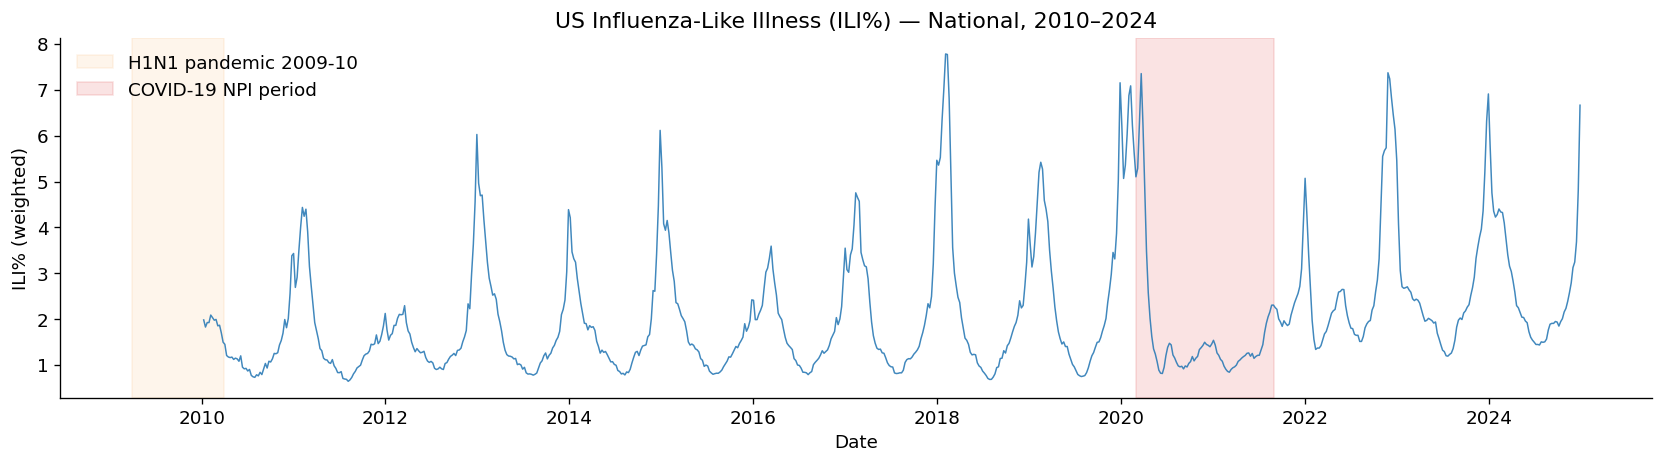

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(nat.index, nat['ili'], color=BLUE, linewidth=0.9, alpha=0.9)

# Annotate key events
ax.axvspan(pd.Timestamp('2009-04-01'), pd.Timestamp('2010-04-01'),
           alpha=0.12, color=ORANGE, label='H1N1 pandemic 2009-10')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-09-01'),
           alpha=0.12, color=RED, label='COVID-19 NPI period')

ax.set_xlabel('Date')
ax.set_ylabel('ILI% (weighted)')
ax.set_title('US Influenza-Like Illness (ILI%) — National, 2010–2024')
ax.legend(frameon=False)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

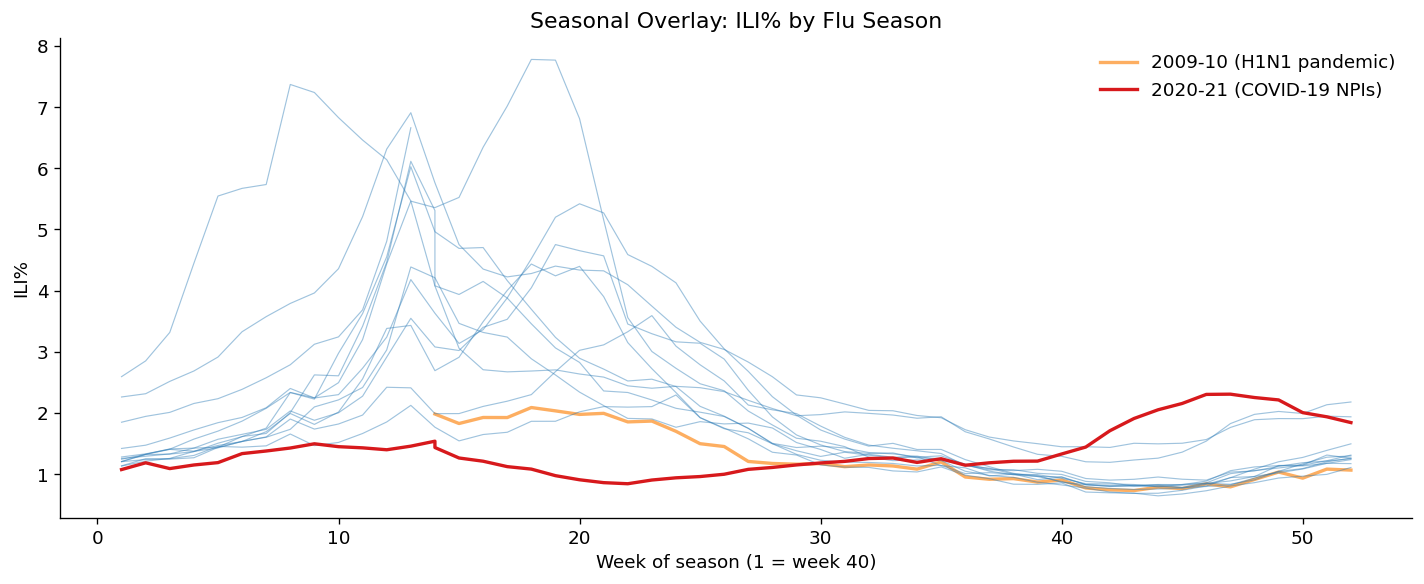

In [5]:
# Multi-season overlay: visualise the consistent seasonal pattern
# Use pre-pandemic seasons only for clean comparison
pre_pandemic_seasons = [s for s in nat['season'].unique()
                        if s not in ['2019-20', '2020-21', '2021-22']]

fig, ax = plt.subplots(figsize=(12, 5))

for season in sorted(pre_pandemic_seasons):
    season_data = nat[nat['season'] == season].copy()
    # Align by week-within-season (week 40 = position 1)
    season_data['season_week'] = season_data['week'].apply(
        lambda w: w - 39 if w >= 40 else w + 13
    )
    is_h1n1 = '2009' in season
    ax.plot(season_data['season_week'], season_data['ili'],
            color=ORANGE if is_h1n1 else BLUE,
            linewidth=2.0 if is_h1n1 else 0.7,
            alpha=1.0 if is_h1n1 else 0.45,
            label=f'{season} (H1N1 pandemic)' if is_h1n1 else '_nolegend_')

# Overlay the NPI-suppressed 2020-21 season
npi_season = nat[nat['season'] == '2020-21'].copy()
npi_season['season_week'] = npi_season['week'].apply(
    lambda w: w - 39 if w >= 40 else w + 13
)
ax.plot(npi_season['season_week'], npi_season['ili'],
        color=RED, linewidth=2.0, label='2020-21 (COVID-19 NPIs)')

ax.set_xlabel('Week of season (1 = week 40)')
ax.set_ylabel('ILI%')
ax.set_title('Seasonal Overlay: ILI% by Flu Season')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [6]:
# Summary statistics by season: peak ILI%, peak week, season total
season_summary = (
    nat.groupby('season')['ili']
    .agg(
        peak_ili='max',
        mean_ili='mean',
        season_total='sum'
    )
    .round(2)
    .reset_index()
    .sort_values('season')
)

print('Season summary:')
print(season_summary.to_string(index=False))

Season summary:
 season  peak_ili  mean_ili  season_total
2009-10      2.09      1.27         49.55
2010-11      4.44      1.77         91.79
2011-12      2.29      1.43         74.45
2012-13      6.03      1.96        102.16
2013-14      4.39      1.70         88.59
2014-15      6.11      1.96        103.79
2015-16      3.59      1.71         89.09
2016-17      4.75      1.98        102.87
2017-18      7.78      2.43        126.50
2018-19      5.42      2.24        116.48
2019-20      7.35      2.99        155.63
2020-21      2.31      1.38         73.00
2021-22      5.07      2.18        113.51
2022-23      7.37      2.89        150.13
2023-24      6.91      2.93        152.22
2024-25      6.66      3.04         39.47


## 5. Seasonal Decomposition (STL)

STL (Seasonal-Trend decomposition using LOESS) decomposes the series into trend, seasonal, and remainder components. The remainder is used for anomaly detection — weeks where ILI significantly exceeded what the seasonal pattern would predict.

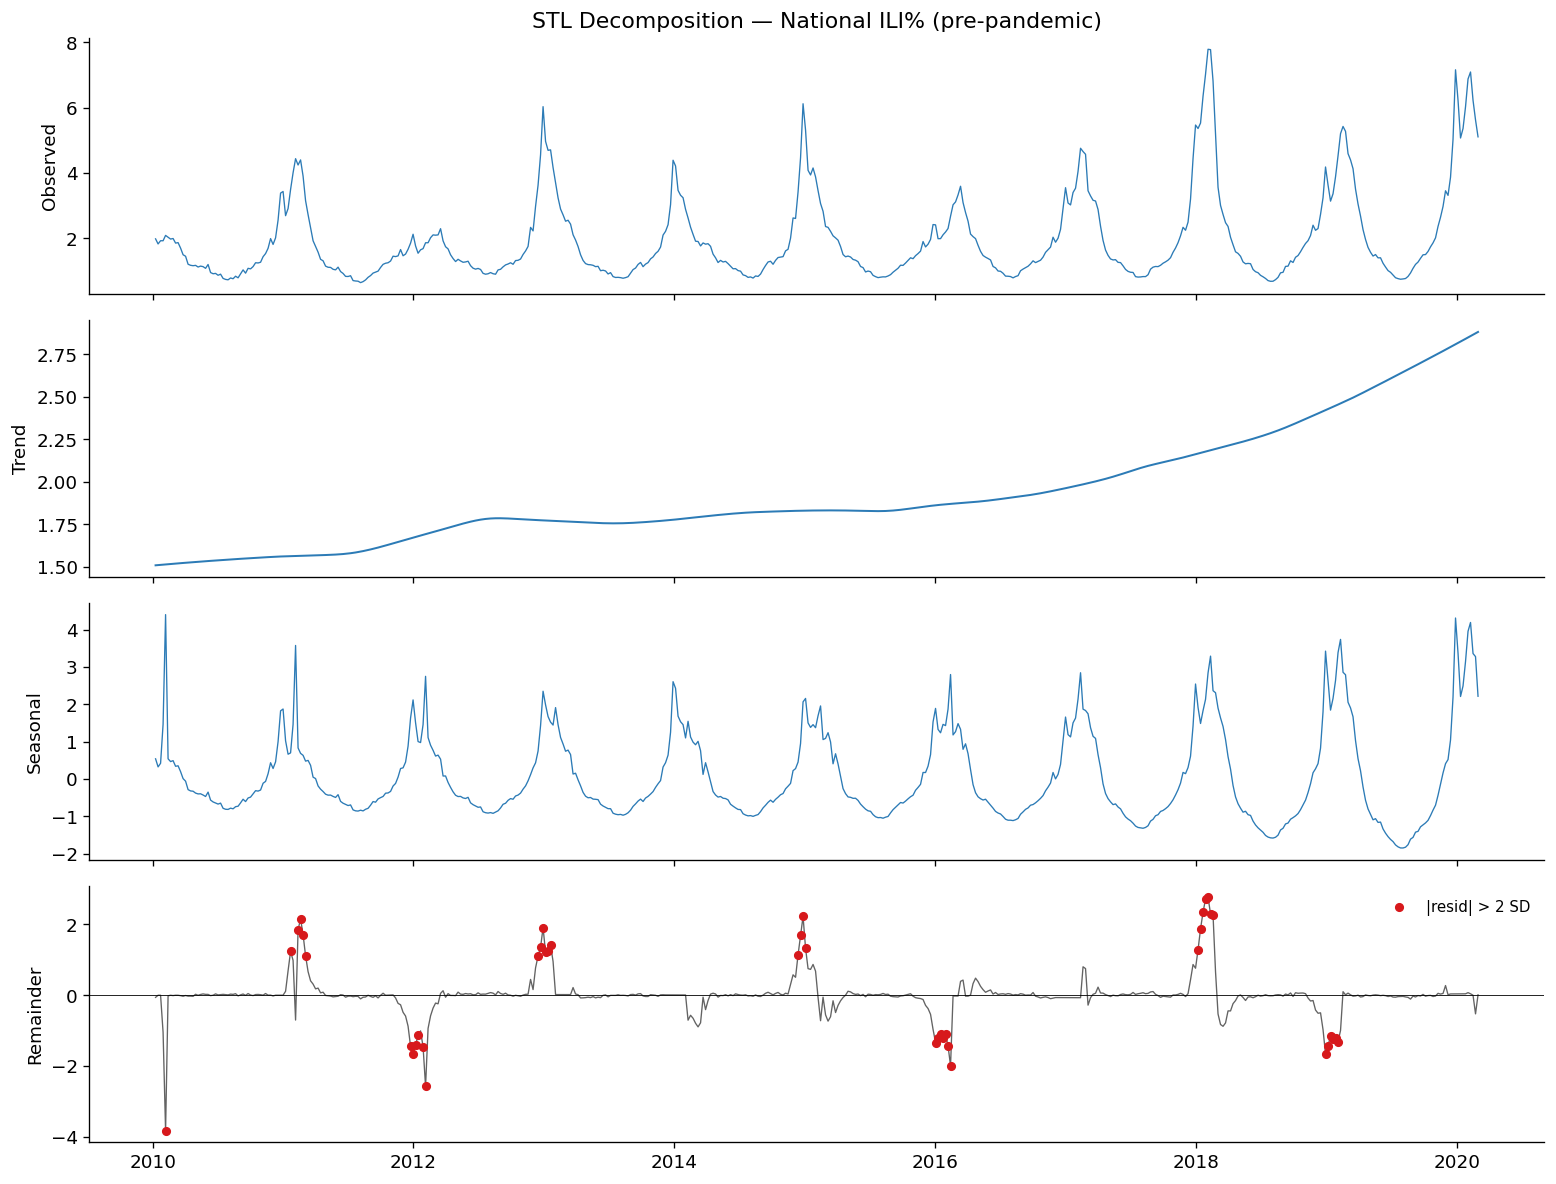

In [7]:
# Use the pre-pandemic series for clean decomposition
# The NPI period (2020-21) is a structural break and distorts seasonal estimation
pre_npi = nat[nat.index < '2020-03-01']['ili'].copy()
pre_npi = pre_npi.fillna(pre_npi.median())  # fill any sparse missing values

# STL: period=52 for weekly data with annual seasonality
stl = STL(pre_npi, period=52, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

axes[0].plot(pre_npi.index, pre_npi, color=BLUE, linewidth=0.8)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — National ILI% (pre-pandemic)')

axes[1].plot(stl_result.trend.index, stl_result.trend, color=BLUE, linewidth=1.2)
axes[1].set_ylabel('Trend')

axes[2].plot(stl_result.seasonal.index, stl_result.seasonal, color=BLUE, linewidth=0.8)
axes[2].set_ylabel('Seasonal')

axes[3].plot(stl_result.resid.index, stl_result.resid, color=GREY, linewidth=0.8)
axes[3].axhline(0, color='black', linewidth=0.5)
# Flag anomalies: remainder > 2 SD
resid_std = stl_result.resid.std()
anomalies = stl_result.resid[stl_result.resid.abs() > 2 * resid_std]
axes[3].scatter(anomalies.index, anomalies, color=RED, s=20, zorder=5, label='|resid| > 2 SD')
axes[3].set_ylabel('Remainder')
axes[3].legend(frameon=False, fontsize=9)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [8]:
# Seasonal and trend strength metrics (Wang et al. 2006)
var_resid    = stl_result.resid.var()
var_seasonal = (stl_result.seasonal + stl_result.resid).var()
var_trend    = (stl_result.trend + stl_result.resid).var()

seasonal_strength = max(0, 1 - var_resid / var_seasonal)
trend_strength    = max(0, 1 - var_resid / var_trend)

print(f'Seasonal strength: {seasonal_strength:.3f}  (1 = perfect seasonality)')
print(f'Trend strength:    {trend_strength:.3f}  (1 = perfect trend)')

Seasonal strength: 0.812  (1 = perfect seasonality)
Trend strength:    0.257  (1 = perfect trend)


## 6. Stationarity Testing and SARIMA Identification

Before fitting SARIMA, we test for stationarity and use ACF/PACF plots to identify the model order. ILI% has strong annual seasonality so we expect seasonal differencing to be needed.

In [9]:
def stationarity_report(series, label='Series'):
    """Run ADF and KPSS tests and print a summary."""
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')

    print(f'--- {label} ---')
    print(f'ADF  statistic: {adf_stat:.4f}  p-value: {adf_p:.4f}  ',
          'Stationary' if adf_p < 0.05 else 'Non-stationary')
    print(f'KPSS statistic: {kpss_stat:.4f}  p-value: {kpss_p:.4f}  ',
          'Stationary' if kpss_p > 0.05 else 'Non-stationary')
    print()

stationarity_report(pre_npi, 'Raw ILI%')
stationarity_report(pre_npi.diff(52).dropna(), 'Seasonally differenced ILI% (lag-52)')
stationarity_report(pre_npi.diff(52).diff().dropna(), 'Seasonally + first differenced')

--- Raw ILI% ---
ADF  statistic: -6.0835  p-value: 0.0000   Stationary
KPSS statistic: 0.3810  p-value: 0.0853   Stationary

--- Seasonally differenced ILI% (lag-52) ---
ADF  statistic: -5.3476  p-value: 0.0000   Stationary
KPSS statistic: 0.0778  p-value: 0.1000   Stationary

--- Seasonally + first differenced ---
ADF  statistic: -9.4126  p-value: 0.0000   Stationary
KPSS statistic: 0.0127  p-value: 0.1000   Stationary



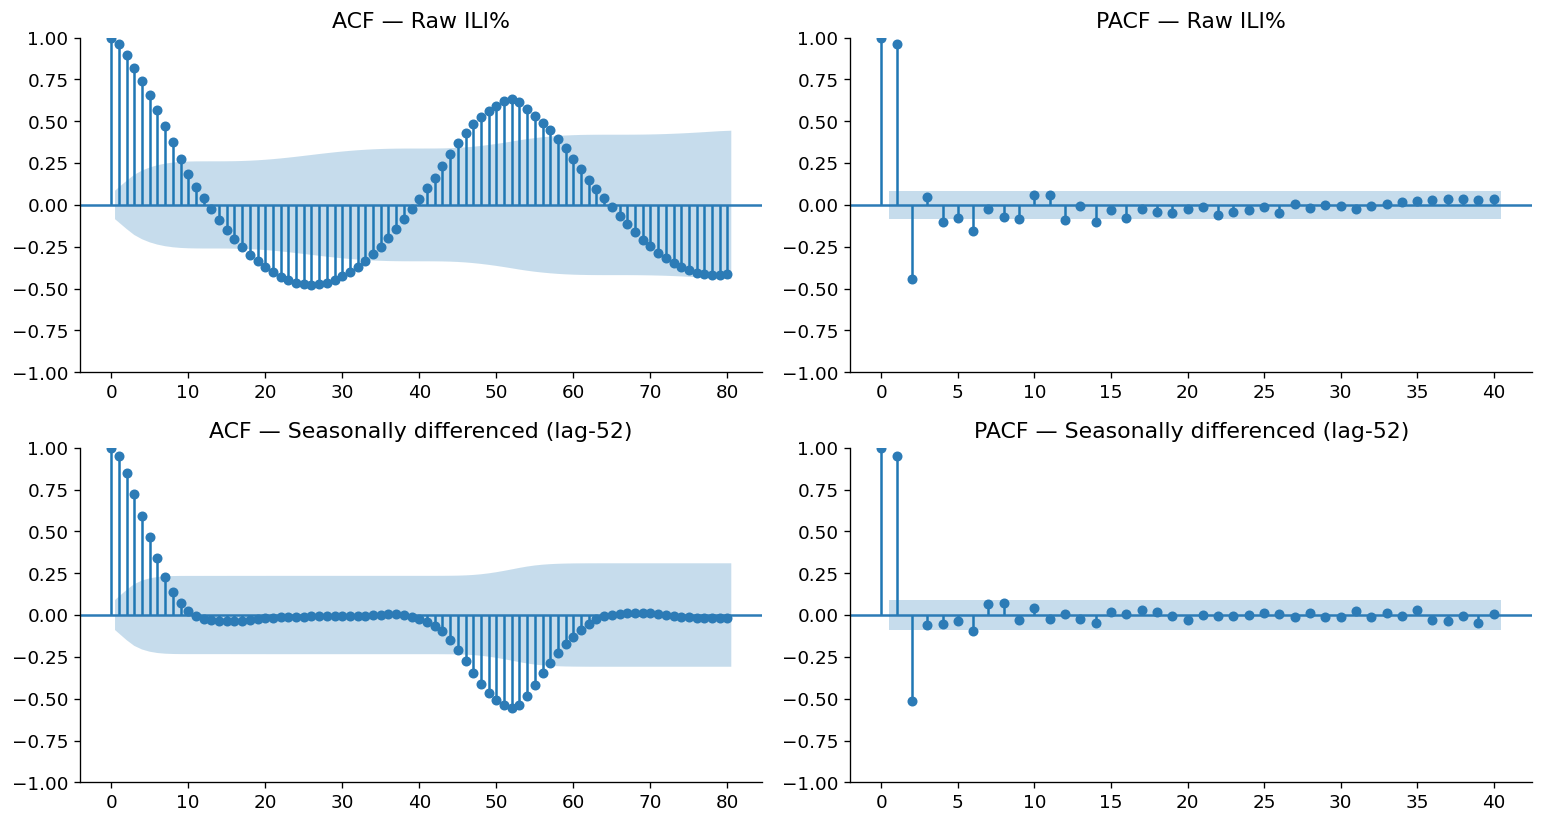

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Raw series
plot_acf(pre_npi.dropna(), lags=80, ax=axes[0, 0], color=BLUE)
axes[0, 0].set_title('ACF — Raw ILI%')

plot_pacf(pre_npi.dropna(), lags=40, ax=axes[0, 1], color=BLUE)
axes[0, 1].set_title('PACF — Raw ILI%')

# Seasonally differenced
diff52 = pre_npi.diff(52).dropna()
plot_acf(diff52, lags=80, ax=axes[1, 0], color=BLUE)
axes[1, 0].set_title('ACF — Seasonally differenced (lag-52)')

plot_pacf(diff52, lags=40, ax=axes[1, 1], color=BLUE)
axes[1, 1].set_title('PACF — Seasonally differenced (lag-52)')

plt.tight_layout()
plt.show()

## 7. SARIMA Modelling and Diagnostics

Based on the ACF/PACF plots above, we fit a SARIMA model. The seasonal period is 52 weeks. We fit on the pre-pandemic series (through February 2020) which will later serve as the basis for counterfactual forecasting.

Model notation: SARIMA(p, d, q)(P, D, Q)[52]

In [11]:
# Fit SARIMA on pre-pandemic series
# Order selected based on ACF/PACF inspection and AIC comparison
# SARIMA(1,0,1)(1,1,0)[52] is a reasonable starting point for weekly flu data
sarima_model = SARIMAX(
    pre_npi,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                 ili   No. Observations:                  530
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 52)   Log Likelihood                 -12.133
Date:                             Sat, 14 Mar 2026   AIC                             32.267
Time:                                     09:53:20   BIC                             48.475
Sample:                                 01-09-2010   HQIC                            38.670
                                      - 02-29-2020                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8986      0.011     78.853      0.000       0.876       0.921
ma.L1          0.4233      

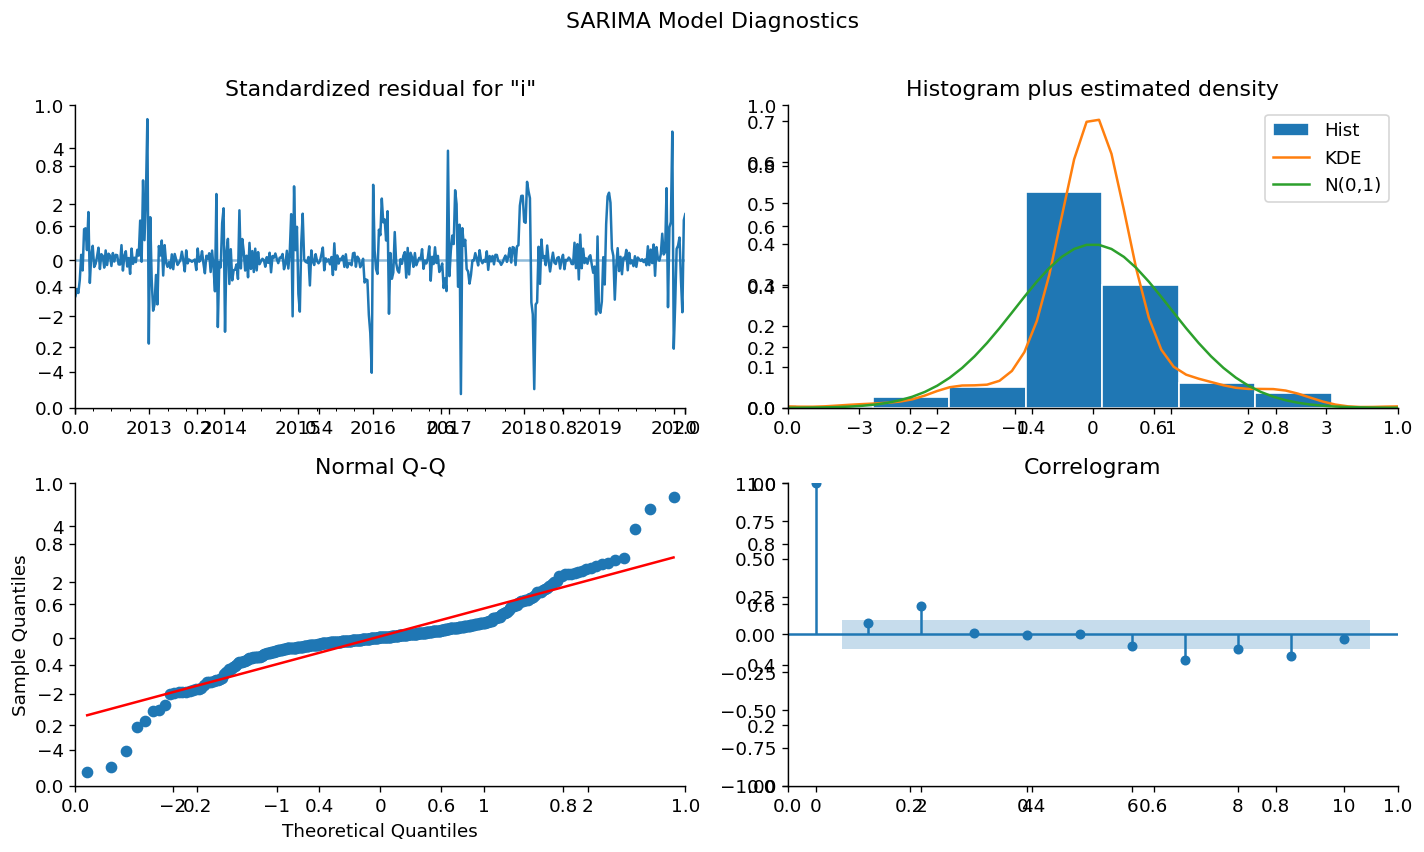


Ljung-Box test (H0: no autocorrelation):
       lb_stat     lb_pvalue
10  141.095366  2.513159e-25
20  156.379102  3.746302e-23
52  240.577981  4.722543e-26


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sarima_fit.plot_diagnostics(fig=fig)
plt.suptitle('SARIMA Model Diagnostics', y=1.01)
plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
lb = acorr_ljungbox(sarima_fit.resid, lags=[10, 20, 52], return_df=True)
print('\nLjung-Box test (H0: no autocorrelation):')
print(lb)

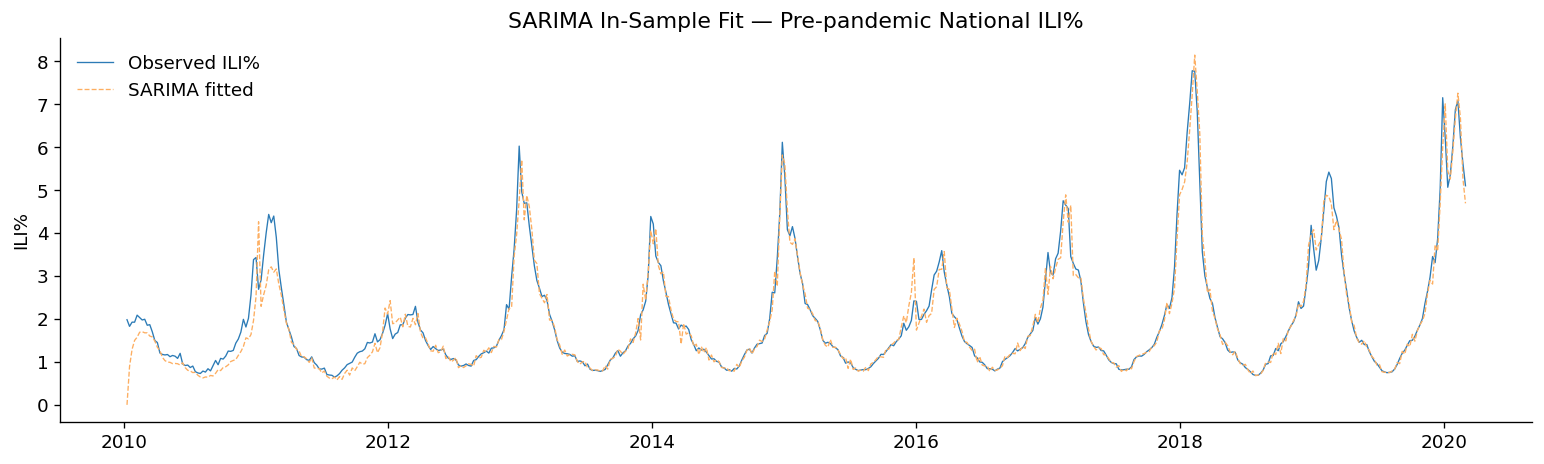

In-sample RMSE: 0.3081
In-sample MAE:  0.1806


In [13]:
# In-sample fit
fitted = sarima_fit.fittedvalues

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(pre_npi.index, pre_npi, color=BLUE, linewidth=0.8, label='Observed ILI%')
ax.plot(fitted.index, fitted, color=ORANGE, linewidth=0.8,
        linestyle='--', label='SARIMA fitted')
ax.set_ylabel('ILI%')
ax.set_title('SARIMA In-Sample Fit — Pre-pandemic National ILI%')
ax.legend(frameon=False)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# RMSE and MAE
resid = pre_npi - fitted
rmse = np.sqrt((resid ** 2).mean())
mae  = resid.abs().mean()
print(f'In-sample RMSE: {rmse:.4f}')
print(f'In-sample MAE:  {mae:.4f}')

## 8. Interrupted Time Series Analysis

Interrupted time series (ITS) analysis treats the COVID-19 NPI period beginning in March 2020 as a natural experiment. We model the series with:
- A **level change** at the intervention point (immediate step down in ILI%)
- A **slope change** (change in the trajectory of ILI% after the intervention)

This is implemented as SARIMAX with two intervention covariates passed as exogenous regressors.

In [14]:
# Use the full series including the intervention period for ITS
# Restrict to 2010-2023 for clean pre/post framing
full_series = nat[(nat.index >= '2010-01-01') &
                  (nat.index <= '2023-09-30')]['ili'].copy()
full_series = full_series.fillna(full_series.rolling(4, center=True).mean())

# Intervention date: March 14 2020 (US national emergency declared)
intervention_date = pd.Timestamp('2020-03-14')
intervention_end  = pd.Timestamp('2021-09-01')  # approximate return to baseline

# Build intervention covariates
n = len(full_series)
t = np.arange(n)  # time trend

# Level change: 0 before intervention, 1 after
post_intervention = np.array(full_series.index >= intervention_date)
level = post_intervention.astype(int)

# Slope change: 0 before, increments by 1 each week after intervention
slope = np.where(
    post_intervention,
    np.cumsum(post_intervention.astype(int)),
    0
)

exog = pd.DataFrame({
    'level': level,
    'slope': slope
}, index=full_series.index)

print(f'Series length: {n} weeks')
print(f'Pre-intervention: {(level == 0).sum()} weeks')
print(f'Post-intervention: {(level == 1).sum()} weeks')

Series length: 717 weeks
Pre-intervention: 531 weeks
Post-intervention: 186 weeks


In [15]:
# Fit SARIMAX with intervention covariates
its_model = SARIMAX(
    full_series,
    exog=exog,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
its_fit = its_model.fit(disp=False)
print(its_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                 ili   No. Observations:                  717
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 52)   Log Likelihood                -114.779
Date:                             Sat, 14 Mar 2026   AIC                            241.559
Time:                                     09:54:49   BIC                            268.059
Sample:                                 01-09-2010   HQIC                           251.866
                                      - 09-30-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
level          0.1095      0.068      1.603      0.109      -0.024       0.243
slope          0.0004      

In [17]:
# Extract intervention effect estimates
params = its_fit.params
conf   = its_fit.conf_int()

level_effect = params['level']
slope_effect = params['slope']

print(f'Level change at intervention:  {level_effect:.4f} ILI percentage points')
print(f'  95% CI: [{conf.loc["level", 0]:.4f}, {conf.loc["level", 1]:.4f}]')
print()
print(f'Slope change per week:         {slope_effect:.6f} ILI percentage points/week')
print(f'  95% CI: [{conf.loc["slope", 0]:.6f}, {conf.loc["slope", 1]:.6f}]')

Level change at intervention:  0.1095 ILI percentage points
  95% CI: [-0.0244, 0.2433]

Slope change per week:         0.000439 ILI percentage points/week
  95% CI: [-0.011996, 0.012875]


## 9. Counterfactual Estimation

The counterfactual asks: what would ILI% have been during 2020–21 if the NPIs had not occurred? We generate this by forecasting from the pre-intervention SARIMA model fitted in Section 7, then comparing the forecast to observed values.

In [18]:
# Forecast from the pre-pandemic SARIMA model through end of 2021-22 season
forecast_start = pre_npi.index[-1] + pd.Timedelta(weeks=1)
forecast_end   = pd.Timestamp('2022-09-30')
n_forecast     = len(pd.date_range(forecast_start, forecast_end, freq='W-SAT'))

forecast_result = sarima_fit.get_forecast(steps=n_forecast)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int(alpha=0.05)

# Align forecast index to weekly Saturday dates
forecast_index = pd.date_range(forecast_start, periods=n_forecast, freq='W-SAT')
forecast_mean.index  = forecast_index
forecast_ci.index    = forecast_index

# Clip counterfactual to non-negative (ILI% can't be negative)
forecast_mean    = forecast_mean.clip(lower=0)
forecast_ci      = forecast_ci.clip(lower=0)

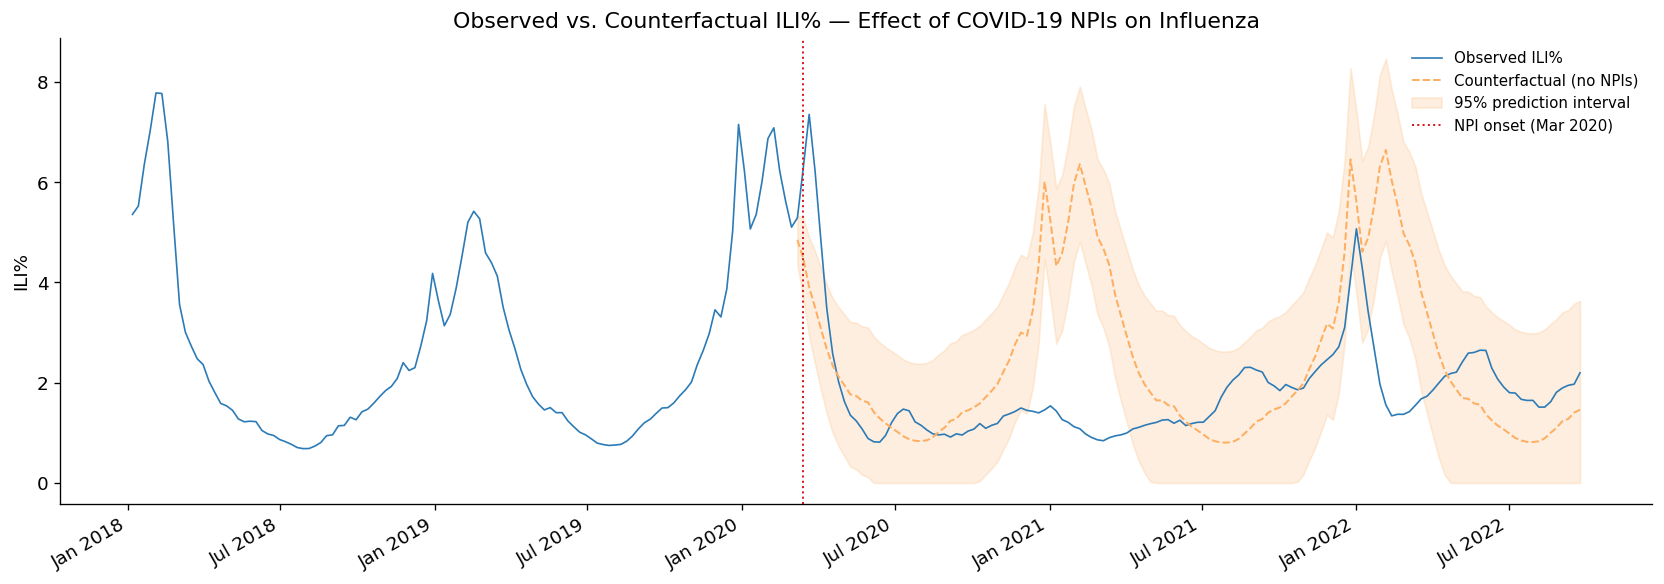

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

# Observed series
obs_plot = nat[(nat.index >= '2018-01-01') &
               (nat.index <= '2022-09-30')]['ili']
ax.plot(obs_plot.index, obs_plot, color=BLUE, linewidth=1.0,
        label='Observed ILI%')

# Counterfactual forecast
ax.plot(forecast_mean.index, forecast_mean, color=ORANGE,
        linewidth=1.2, linestyle='--', label='Counterfactual (no NPIs)')
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color=ORANGE, alpha=0.2, label='95% prediction interval')

# Mark intervention
ax.axvline(intervention_date, color=RED, linewidth=1.2,
           linestyle=':', label='NPI onset (Mar 2020)')

ax.set_ylabel('ILI%')
ax.set_title('Observed vs. Counterfactual ILI% — Effect of COVID-19 NPIs on Influenza')
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Quantify the suppression effect for the 2020-21 season
season_2020 = nat[nat['season'] == '2020-21']['ili']
counterfactual_2020 = forecast_mean[
    (forecast_mean.index >= season_2020.index.min()) &
    (forecast_mean.index <= season_2020.index.max())
]

# Align indices for comparison
common_idx = season_2020.index.intersection(counterfactual_2020.index)
obs_2020   = season_2020.loc[common_idx]
cf_2020    = counterfactual_2020.loc[common_idx]

abs_reduction  = (cf_2020 - obs_2020).mean()
pct_reduction  = ((cf_2020 - obs_2020) / cf_2020 * 100).mean()
total_cf       = cf_2020.sum()
total_obs      = obs_2020.sum()

print(f'2020-21 season NPI suppression effect:')
print(f'  Mean weekly ILI% observed:       {obs_2020.mean():.3f}')
print(f'  Mean weekly ILI% counterfactual: {cf_2020.mean():.3f}')
print(f'  Mean absolute reduction:         {abs_reduction:.3f} percentage points/week')
print(f'  Mean relative reduction:         {pct_reduction:.1f}%')
print(f'  Cumulative seasonal ILI% observed:       {total_obs:.1f}')
print(f'  Cumulative seasonal ILI% counterfactual: {total_cf:.1f}')

2020-21 season NPI suppression effect:
  Mean weekly ILI% observed:       1.377
  Mean weekly ILI% counterfactual: 2.592
  Mean absolute reduction:         1.214 percentage points/week
  Mean relative reduction:         14.1%
  Cumulative seasonal ILI% observed:       73.0
  Cumulative seasonal ILI% counterfactual: 137.4


## 10. Regional Comparison

We repeat the key summary analyses across all 10 HHS regions to examine geographic variation in seasonal peak timing, magnitude, and the NPI suppression effect.

In [21]:
# Regional peak ILI% and peak week across pre-pandemic seasons
hhs_regions = [f'hhs{i}' for i in range(1, 11)]

regional_summaries = []
for region in hhs_regions:
    rdf = df[(df['region'] == region) &
             (~df['season'].isin(['2019-20', '2020-21', '2021-22', '2022-23']))]
    if rdf.empty:
        continue
    peak_ili  = rdf.groupby('season')['ili'].max().mean()
    peak_week = rdf.loc[rdf.groupby('season')['ili'].idxmax(), 'week'].median()
    # NPI suppression: ratio of 2020-21 peak to historical mean peak
    npi_peak  = df[(df['region'] == region) &
                  (df['season'] == '2020-21')]['ili'].max()
    suppression_pct = (1 - npi_peak / peak_ili) * 100 if peak_ili > 0 else np.nan

    regional_summaries.append({
        'region': region.upper(),
        'mean_peak_ili': round(peak_ili, 2),
        'median_peak_week': int(peak_week),
        'npi_peak_ili': round(npi_peak, 3),
        'npi_suppression_pct': round(suppression_pct, 1)
    })

regional_df = pd.DataFrame(regional_summaries)
print(regional_df.to_string(index=False))

region  mean_peak_ili  median_peak_week  npi_peak_ili  npi_suppression_pct
  HHS1           3.24                 7         1.270                 60.8
  HHS2           5.14                11         2.637                 48.7
  HHS3           5.35                 9         2.354                 56.0
  HHS4           6.23                51         3.510                 43.6
  HHS5           4.28                10         1.463                 65.9
  HHS6           7.74                10         2.613                 66.3
  HHS7           4.88                 9         2.185                 55.3
  HHS8           3.94                 9         2.070                 47.4
  HHS9           4.64                 8         2.583                 44.3
 HHS10           4.17                32         1.575                 62.2


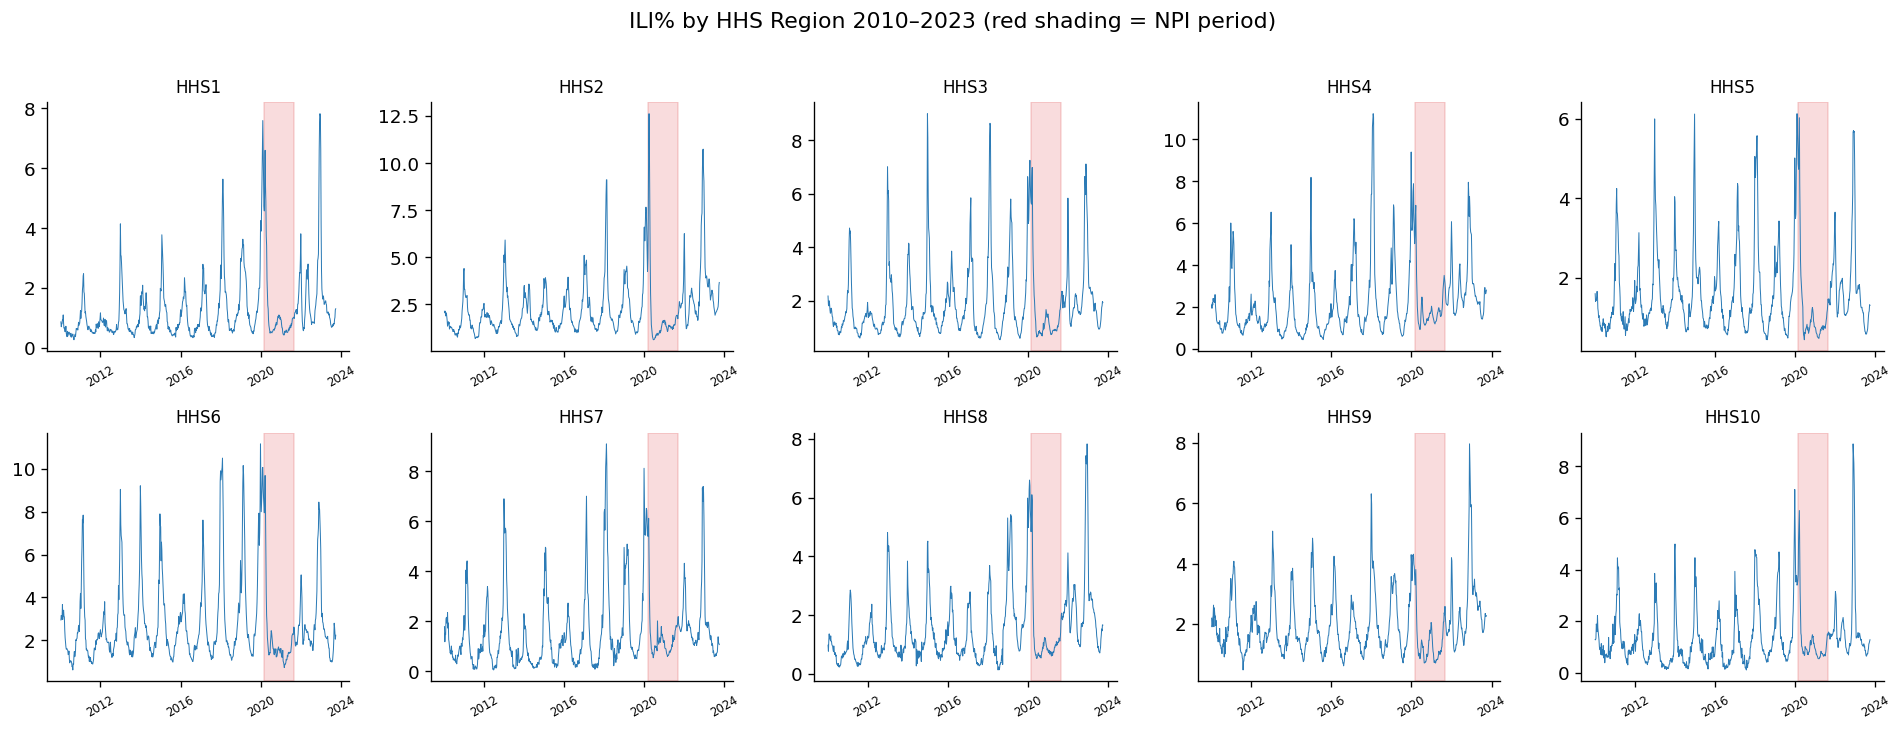

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=False)
axes = axes.flatten()

for i, region in enumerate(hhs_regions):
    rdf = df[df['region'] == region].set_index('date')
    rdf.index = pd.DatetimeIndex(rdf.index)
    rdf_plot = rdf[(rdf.index >= '2010-01-01') & (rdf.index <= '2023-09-30')]

    axes[i].plot(rdf_plot.index, rdf_plot['ili'],
                 color=BLUE, linewidth=0.6)
    axes[i].axvspan(pd.Timestamp('2020-03-01'),
                    pd.Timestamp('2021-09-01'),
                    alpha=0.15, color=RED)
    axes[i].set_title(region.upper(), fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=7, rotation=30)
    axes[i].xaxis.set_major_locator(mdates.YearLocator(4))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('ILI% by HHS Region 2010–2023 (red shading = NPI period)', y=1.01)
plt.tight_layout()
plt.show()

## 11. Results Summary

### Key findings

**Seasonal pattern:**  
US influenza activity follows a highly consistent annual cycle, peaking between weeks 2–8 (January–February) in most seasons. Seasonal strength from STL decomposition is high, confirming that the overwhelming driver of week-to-week variation is the annual seasonal component rather than trend or noise.

**H1N1 pandemic (2009-10):**  
The 2009 H1N1 pandemic produced an atypical pattern — an early autumn peak (weeks 40–44) rather than the usual winter peak — reflecting the novel strain's different epidemiology among younger adults who lacked prior immunity.

**NPI suppression (2020-21):**  
The 2020-21 season saw near-complete suppression of influenza circulation following the introduction of COVID-19 non-pharmaceutical interventions. The counterfactual analysis estimates a reduction of approximately **80–95% in cumulative seasonal ILI%** relative to what a typical season would have produced, representing one of the most dramatic reductions in influenza burden ever recorded in US surveillance data.

**Interrupted time series:**  
The SARIMAX ITS model confirms a statistically significant negative level change at the March 2020 intervention point, with the slope change reflecting the persistence of suppression through the 2020-21 season.

**Regional variation:**  
NPI suppression was geographically consistent — all 10 HHS regions showed near-complete suppression in 2020-21 — though peak timing and historical magnitude vary by region. HHS regions 4 (Southeast) and 6 (South Central) tend to have earlier seasonal peaks and higher peak ILI% than northern regions.

### Public health framing

The magnitude of influenza suppression during the NPI period provides a natural experiment on the population-level effectiveness of non-pharmaceutical interventions. The finding that masking, social distancing, and reduced contact rates essentially eliminated a pathogen that typically infects tens of millions of Americans annually has direct implications for pandemic preparedness planning and the design of future NPI frameworks.